# Gene-grouped nested cross-validation (CatBoost)

**Stage 1 — honest performance only.** Compare to XGBoost on the **same gene folds**.
Do not take a deploy config from this notebook.

Logic: `src/cv_baselines.py`. CatBoost uses **native categoricals** (same columns as
XGBoost), not one-hot. Logistic / random forest are the models that one-hot encode.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
)


In [2]:
load_dotenv()
project_root = Path(os.environ["PROJECT_ROOT"])
sys.path.insert(0, str(project_root / "src"))

from cv_baselines import PARAM_DISTRIBUTIONS, run_nested_cv_baseline
from cv_train_eval import run_cv_folds
from features import FEATURE_COLUMNS, GROUP_COLUMN, split_summary

ESTIMATOR = "catboost"
N_FOLDS = 5
SEED = 42
N_TUNING_TRIALS = 12
MODELS_DIR = project_root / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("estimator:", ESTIMATOR)
print("features:", FEATURE_COLUMNS)
print("search space:", PARAM_DISTRIBUTIONS[ESTIMATOR])


estimator: catboost
features: ['protein_position', 'relative_protein_position', 'distance_to_closest_feature', 'has_protein_position', 'in_domain', 'in_region', 'in_zinc_finger', 'in_active_site', 'in_binding_site', 'in_disulfide', 'in_mod_res', 'in_functional_site', 'in_any_feature', 'closest_feature_type', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']
search space: {'depth': [4, 6, 8], 'learning_rate': [0.03, 0.05, 0.1], 'l2_leaf_reg': [1.0, 3.0, 5.0], 'subsample': [0.7, 0.8, 0.9]}


## Assign CV folds

Reuse the same gene assignment as XGBoost (`run_cv_folds()` → `data/processed/cv_folds.parquet`, seed 42).


In [3]:
folded = run_cv_folds(n_folds=N_FOLDS, seed=SEED)
display(split_summary(folded, partition_col="fold"))

gene_folds = folded.groupby(GROUP_COLUMN)["fold"].nunique()
assert (gene_folds == 1).all()
print(
    f"{folded[GROUP_COLUMN].nunique()} genes, {len(folded)} variants, "
    "gene overlap across folds: none"
)


,fold,n_variants,n_genes,pct_pathogenic,pct_with_protein_position
0,0,2313,19,35.538262,77.086035
1,1,2313,26,41.980112,74.189364
2,2,2313,31,52.053610,76.394293
3,3,2312,30,74.134948,80.449827
4,4,2312,31,70.977509,81.833910


137 genes, 11563 variants, gene overlap across folds: none


## Nested CV: tune θ, iterations, and decision threshold

`run_nested_cv_baseline("catboost")` on the outer-train pool only:

1. Each fit uses `auto_class_weights="Balanced"`
2. Inner CV picks depth / learning rate / L2 / subsample, plus tree budget
   (median `best_iteration+1` from inner early stopping)
3. Probability cutoff = **median of per-inner-fold** Youden thresholds
4. Refit on the full pool with that tree budget; apply the cutoff on the outer test fold


In [4]:
THRESHOLD_METHOD = "youden"  # balanced TPR−FPR; alt: "f1" (tends toward all-pathogenic)

cv_result = run_nested_cv_baseline(
    ESTIMATOR,
    folded,
    n_folds=N_FOLDS,
    n_trials=N_TUNING_TRIALS,
    seed=SEED,
    param_distributions=PARAM_DISTRIBUTIONS[ESTIMATOR],
    threshold_method=THRESHOLD_METHOD,
)
fold_metrics = cv_result["fold_metrics"]
oof = cv_result["oof"]
tuning_log = cv_result["tuning_log"]
importance_df = cv_result["importance"]
confusion_total = cv_result["confusion_total"]
cls_summary = cv_result["classification_summary"]
fold_metrics


outer 0: thr=0.462  ROC=0.737  P=0.590  R=0.620  Acc=0.712  n_estimators=59
outer 1: thr=0.460  ROC=0.738  P=0.585  R=0.706  Acc=0.666  n_estimators=68
outer 2: thr=0.538  ROC=0.693  P=0.682  R=0.667  Acc=0.665  n_estimators=69
outer 3: thr=0.506  ROC=0.651  P=0.792  R=0.700  Acc=0.641  n_estimators=63
outer 4: thr=0.522  ROC=0.664  P=0.818  R=0.645  Acc=0.646  n_estimators=26


,n_train,n_test,n_test_genes,best_inner_roc_auc,n_estimators,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,tn,fp,fn,tp,param_subsample,param_learning_rate,param_l2_leaf_reg,param_depth
fold,,,,,,,,,,,,,,,,,,,,
0,9250,2313,19,0.690270,59,0.461901,0.737320,0.570379,0.711630,0.589595,0.620438,0.604624,1136,355,312,510,0.7,0.10,1.0,6
1,9250,2313,26,0.668777,68,0.459926,0.737814,0.651351,0.666234,0.584825,0.706488,0.639925,855,487,285,686,0.7,0.05,5.0,8
2,9250,2313,31,0.671930,69,0.538390,0.692834,0.691069,0.664937,0.682243,0.666944,0.674507,735,374,401,803,0.9,0.10,3.0,6
3,9251,2312,30,0.703982,63,0.506292,0.651047,0.833671,0.641436,0.792465,0.699533,0.743105,284,314,515,1199,0.8,0.05,1.0,8
4,9251,2312,31,0.689360,26,0.521538,0.664221,0.808160,0.646194,0.818252,0.644729,0.721200,436,235,583,1058,0.7,0.10,1.0,6


## Chosen hyperparameters per outer fold

Each outer fold has its own `θ*_k` from **inner CV mean AUC**.


In [5]:
param_cols = [c for c in fold_metrics.columns if c.startswith("param_")]
cols = ["threshold", "roc_auc", "precision", "recall", "accuracy", "f1"]
if fold_metrics["n_estimators"].notna().any():
    cols = ["threshold", "n_estimators"] + cols[1:]
display(fold_metrics[cols + param_cols].round(3))


,threshold,n_estimators,roc_auc,precision,recall,accuracy,f1,param_subsample,param_learning_rate,param_l2_leaf_reg,param_depth
fold,,,,,,,,,,,
0,0.462,59,0.737,0.590,0.620,0.712,0.605,0.7,0.10,1.0,6
1,0.460,68,0.738,0.585,0.706,0.666,0.640,0.7,0.05,5.0,8
2,0.538,69,0.693,0.682,0.667,0.665,0.675,0.9,0.10,3.0,6
3,0.506,63,0.651,0.792,0.700,0.641,0.743,0.8,0.05,1.0,8
4,0.522,26,0.664,0.818,0.645,0.646,0.721,0.7,0.10,1.0,6


## Operating-point detail (confusion + per-fold)


,threshold,accuracy,precision,recall,f1
mean,0.498,0.666,0.693,0.668,0.677
std,0.035,0.028,0.110,0.036,0.057
min,0.460,0.641,0.585,0.620,0.605
max,0.538,0.712,0.818,0.706,0.743


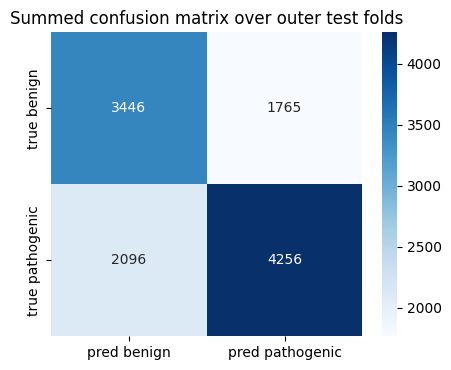

,threshold,roc_auc,pr_auc,precision,recall,accuracy,f1,tn,fp,fn,tp
fold,,,,,,,,,,,
0,0.462,0.737,0.570,0.590,0.620,0.712,0.605,1136,355,312,510
1,0.460,0.738,0.651,0.585,0.706,0.666,0.640,855,487,285,686
2,0.538,0.693,0.691,0.682,0.667,0.665,0.675,735,374,401,803
3,0.506,0.651,0.834,0.792,0.700,0.641,0.743,284,314,515,1199
4,0.522,0.664,0.808,0.818,0.645,0.646,0.721,436,235,583,1058


In [6]:
display(cls_summary.round(3))

cm = np.array(
    [
        [confusion_total["tn"], confusion_total["fp"]],
        [confusion_total["fn"], confusion_total["tp"]],
    ]
)
fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["pred benign", "pred pathogenic"],
    yticklabels=["true benign", "true pathogenic"],
    ax=ax,
)
ax.set_title("Summed confusion matrix over outer test folds")
fig.tight_layout()
plt.show()

display(
    fold_metrics[
        ["threshold", "roc_auc", "pr_auc", "precision", "recall", "accuracy", "f1", "tn", "fp", "fn", "tp"]
    ].round(3)
)


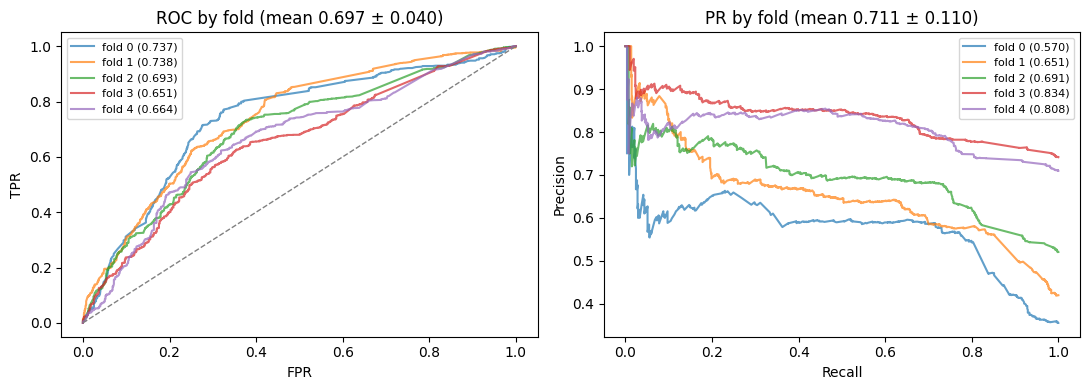

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

mean_roc = fold_metrics["roc_auc"].mean()
std_roc = fold_metrics["roc_auc"].std()
mean_pr = fold_metrics["pr_auc"].mean()
std_pr = fold_metrics["pr_auc"].std()

for fold, part in oof.groupby("fold"):
    fpr, tpr, _ = roc_curve(part["y_true"], part["y_proba"])
    axes[0].plot(
        fpr,
        tpr,
        alpha=0.7,
        label=f"fold {fold} ({roc_auc_score(part['y_true'], part['y_proba']):.3f})",
    )
    prec, rec, _ = precision_recall_curve(part["y_true"], part["y_proba"])
    axes[1].plot(
        rec,
        prec,
        alpha=0.7,
        label=f"fold {fold} ({average_precision_score(part['y_true'], part['y_proba']):.3f})",
    )

axes[0].plot([0, 1], [0, 1], ls="--", c="gray", lw=1)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title(f"ROC by fold (mean {mean_roc:.3f} ± {std_roc:.3f})")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"PR by fold (mean {mean_pr:.3f} ± {std_pr:.3f})")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()


## Feature importance across folds

Native CatBoost importances (same feature names as XGBoost; no one-hot).


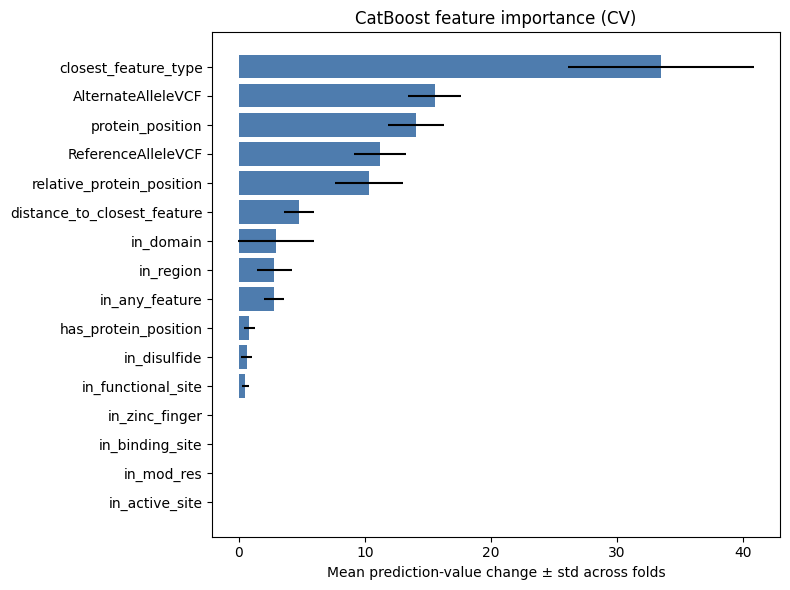

,mean,std
closest_feature_type,33.5061,7.3752
AlternateAlleleVCF,15.5477,2.0846
protein_position,14.0506,2.2099
ReferenceAlleleVCF,11.2254,2.0753
relative_protein_position,10.3128,2.7080
distance_to_closest_feature,4.7738,1.1626
in_domain,2.9616,3.0174
in_region,2.8027,1.3865
in_any_feature,2.7748,0.7934
has_protein_position,0.8514,0.4684


In [8]:
top = importance_df.head(20)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    top.index[::-1],
    top["mean"].iloc[::-1],
    xerr=top["std"].iloc[::-1],
    color="#3b6ea5",
    alpha=0.9,
)
ax.set_xlabel("Mean prediction-value change ± std across folds")
ax.set_title("CatBoost feature importance (CV)")
fig.tight_layout()
plt.show()

top[["mean", "std"]].round(4)


## Persist fold predictions

Headline metrics are mean±std across outer folds, not pooled OOF ROC. Compare these tables to `xgb_cv_fold_metrics.csv` on the same folds.


In [9]:
oof_path = MODELS_DIR / "catboost_cv_oof_predictions.parquet"
metrics_path = MODELS_DIR / "catboost_cv_fold_metrics.csv"
tuning_path = MODELS_DIR / "catboost_cv_tuning_log.csv"
oof.to_parquet(oof_path, index=False)
fold_metrics.to_csv(metrics_path)
tuning_log.to_csv(tuning_path, index=False)
print("Saved", oof_path)
print("Saved", metrics_path)
print("Saved", tuning_path)
fold_metrics.round(3)


Saved /home/milijanas/projects/clinvar-pathogenicity-classifier/models/catboost_cv_oof_predictions.parquet
Saved /home/milijanas/projects/clinvar-pathogenicity-classifier/models/catboost_cv_fold_metrics.csv
Saved /home/milijanas/projects/clinvar-pathogenicity-classifier/models/catboost_cv_tuning_log.csv


,n_train,n_test,n_test_genes,best_inner_roc_auc,n_estimators,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,tn,fp,fn,tp,param_subsample,param_learning_rate,param_l2_leaf_reg,param_depth
fold,,,,,,,,,,,,,,,,,,,,
0,9250,2313,19,0.690,59,0.462,0.737,0.570,0.712,0.590,0.620,0.605,1136,355,312,510,0.7,0.10,1.0,6
1,9250,2313,26,0.669,68,0.460,0.738,0.651,0.666,0.585,0.706,0.640,855,487,285,686,0.7,0.05,5.0,8
2,9250,2313,31,0.672,69,0.538,0.693,0.691,0.665,0.682,0.667,0.675,735,374,401,803,0.9,0.10,3.0,6
3,9251,2312,30,0.704,63,0.506,0.651,0.834,0.641,0.792,0.700,0.743,284,314,515,1199,0.8,0.05,1.0,8
4,9251,2312,31,0.689,26,0.522,0.664,0.808,0.646,0.818,0.645,0.721,436,235,583,1058,0.7,0.10,1.0,6


## Conclusion — honest performance KPIs

Gene-grouped **nested** CV on held-out genes (outer mean ± std).
Report these numbers next to XGBoost; do not pick a winner from outer-test scores and then quote only that winner.

**Primary (threshold-free):** ROC-AUC, PR-AUC.  
**Operating point:** precision / recall / accuracy / F1 at the inner-chosen **Youden** cutoff.


In [10]:
def _mean_std(series: pd.Series) -> str:
    return f"{series.mean():.3f} ± {series.std():.3f}"


print(f"Estimator: {ESTIMATOR}")
print(f"Threshold method: {THRESHOLD_METHOD}")
print(f"ROC-AUC     = {_mean_std(fold_metrics['roc_auc'])}")
print(f"PR-AUC      = {_mean_std(fold_metrics['pr_auc'])}")
print(f"Precision   = {_mean_std(fold_metrics['precision'])}")
print(f"Recall      = {_mean_std(fold_metrics['recall'])}")
print(f"Accuracy    = {_mean_std(fold_metrics['accuracy'])}")
print(f"F1          = {_mean_std(fold_metrics['f1'])}")
print(f"Threshold   = {_mean_std(fold_metrics['threshold'])}")


Estimator: catboost
Threshold method: youden
ROC-AUC     = 0.697 ± 0.040
PR-AUC      = 0.711 ± 0.110
Precision   = 0.693 ± 0.110
Recall      = 0.668 ± 0.036
Accuracy    = 0.666 ± 0.028
F1          = 0.677 ± 0.057
Threshold   = 0.498 ± 0.035


### Notes

- Same `cv_folds.parquet` / seed as `cv_xgboost.ipynb`.
- Stage 2 (`notebooks/modeling/final/`) stays XGBoost until a baseline clearly wins on these outer-fold KPIs.
